# Malaria


## 1. Creación de un documento Google Colab
Pasos seguidos para crear y compartir el documento en Google Colab.

### A. Crear un documento en Google Colab
* Primero creamos un repositorio en GitHub para organizar el trabajo del grupo.
* Subimos o preparamos allí los archivos necesarios para la práctica.
* Después abrimos el notebook desde Google Colab, usando la opción de abrir un cuaderno desde GitHub.
* Una vez abierto en Colab, comprobamos que el notebook se podía ejecutar correctamente.
* Además, utilizamos Google Drive para subir los datos necesarios para el análisis, ya que eran archivos externos al notebook.
* Desde Colab vinculamos Google Drive para poder acceder a esos datos durante la ejecución del código.
* Desde este momento utilizamos Google Colab para escribir codigo.

### B. Permitir el acceso a todos los integrantes del grupo
* Pulsamos el botón **Compartir**, situado en la parte superior derecha del documento.
* Añadimos las cuentas de correo de los integrantes del grupo.
* Asignamos los permisos correspondientes, en este caso editor, para que todos pudieran modificar el notebook.
* También se puede configurar el enlace como "Cualquier persona con el enlace", ajustando el permiso según sea necesario: lector, comentador o editor.
* Finalmente, comprobamos que todos los miembros podían acceder al documento desde su cuenta de Google y trabajar sobre el mismo notebook.
* Adicionalmente compartimos tambien el fichero de Google Drive (Malaria Data.zip).

## 2.	Implementación de algoritmos de aprendizaje automático


Se utilizará el conjunto de datos iris que ofrece Seaborn (iris = sns.load_dataset('iris'))

## A. Vectorización de las clases mediante One Hot Encoding


---
## 2A. One Hot Encoding de las clases

La columna `species` contiene tres clases categóricas: *setosa*, *versicolor* y *virginica*.
Aplicamos **One Hot Encoding** para convertirlas en vectores binarios, tal como requieren muchos algoritmos de ML, especialmente redes neuronales.

In [ ]:
import seaborn as sns
import pandas as pd

# En primer lugar definimos y separamos características (X) y etiquetas (y):
X = iris.drop(columns=['species'])
y = iris['species']


# Es recomendable comprobar la existencia de valores faltantes y outliers.
# En caso de existir, valoraremos si dejarlos o no en función del % del dataset
# que representan.

# Comprobación valores faltantes:

filas_con_nan = iris[iris.isna().any(axis=1)]

if filas_con_nan.empty:
    print("Este dataset no contiene valores faltantes.")
else:
    print("Se han detectado valores faltantes en las siguientes filas:")
    print(filas_con_nan)

# Con esto veríamos aquellas filas que tienen al menos un número faltante.
# Como vemos, en este dataset no existen valores faltantes.
# En el caso que hubiera aparecido alguno y quisiéramos quitar las filas
# afectadas usaríamos: iris = iris.dropna(); alternativamente
# podríamos imputar valores para evitar perder datos de otras columnas.



# Comprobación de outliers (valores extremos), que podrían darse por ejemplo
# como consecuencia de errores en las mediciones, pero también ocurrir
# de forma natural. Para ello usamos el método IQR, en que un dato se considera
# outlier si cae fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# donde IQR = Q3 - Q1 (rango intercuartílico):

print('\nDetección de outliers por el método IQR:')
outlier_indices = set()

for col in X.columns:
    Q1  = X[col].quantile(0.25)   # primer cuartil (25%)
    Q3  = X[col].quantile(0.75)   # tercer cuartil (75%)
    IQR = Q3 - Q1                 # rango intercuartílico

    lim_inf = Q1 - 1.5 * IQR     # límite inferior
    lim_sup = Q3 + 1.5 * IQR     # límite superior

    # Filas que caen fuera de los límites
    outliers = X[(X[col] < lim_inf) | (X[col] > lim_sup)]

    print(f'\n{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Rango válido: [{lim_inf:.2f}, {lim_sup:.2f}]')
    print(f'  Outliers encontrados: {len(outliers)}')

    if len(outliers) > 0:
        print(f'  Índices: {list(outliers.index)}')
        outlier_indices.update(outliers.index)

print(f'\nTotal de filas con al menos un outlier: {len(outlier_indices)}')
print(f'Índices: {sorted(outlier_indices)}')

# Decidimos no eliminar filas con outliers para evitar perder datos de otras mediciones.

# A continuación realizamos el One Hot Encoding de las etiquetas (variable 'species'):
y_enc = pd.get_dummies(iris['species'], dtype=int)

# Mostramos el resultado
print('\nUna vez realizado el One-hot encoding, obtenemos:')
print(f'\nVisualización primeras 5 entradas:')
print(y_enc.head())
print(f'\nVisualización entradas 80-84:')
print(y_enc.iloc[80:85])
print(f'\nVisualización últimas 5entradas:')
print(y_enc.tail())

Este dataset no contiene valores faltantes.

Detección de outliers por el método IQR:

sepal_length:
  Q1=5.10, Q3=6.40, IQR=1.30
  Rango válido: [3.15, 8.35]
  Outliers encontrados: 0

sepal_width:
  Q1=2.80, Q3=3.30, IQR=0.50
  Rango válido: [2.05, 4.05]
  Outliers encontrados: 4
  Índices: [15, 32, 33, 60]

petal_length:
  Q1=1.60, Q3=5.10, IQR=3.50
  Rango válido: [-3.65, 10.35]
  Outliers encontrados: 0

petal_width:
  Q1=0.30, Q3=1.80, IQR=1.50
  Rango válido: [-1.95, 4.05]
  Outliers encontrados: 0

Total de filas con al menos un outlier: 4
Índices: [15, 32, 33, 60]

Una vez realizado el One-hot encoding, obtenemos:

Visualización primeras 5 entradas:
   setosa  versicolor  virginica
0       1           0          0
1       1           0          0
2       1           0          0
3       1           0          0
4       1           0          0

Visualización entradas 80-84:
    setosa  versicolor  virginica
80       0           1          0
81       0           1          0
82

Cada especie queda representada como un vector de tres posiciones (una por clase). En nuestro caso:
setosa = `[1, 0, 0]`, versicolor = `[0, 1, 0]`, virginica = `[0, 0, 1]`.

Para los modelos clasificadores usaremos `y` (etiquetas originales) en vez de `y_enc`, ya que `SVC`, `RandomForest` y `GaussianNB` de sklearn aceptan directamente etiquetas categóricas.

In [ ]:
import seaborn as sns
import pandas as pd



iris = sns.load_dataset('iris')
iris['species']

# One Hot Encoding de la variable especie
y_dummy = pd.get_dummies(iris['species'], dtype=int)

print(y_dummy.head())
print(y_dummy.iloc[80:85])
print(y_dummy.tail())

   setosa  versicolor  virginica
0       1           0          0
1       1           0          0
2       1           0          0
3       1           0          0
4       1           0          0
    setosa  versicolor  virginica
80       0           1          0
81       0           1          0
82       0           1          0
83       0           1          0
84       0           1          0
     setosa  versicolor  virginica
145       0           0          1
146       0           0          1
147       0           0          1
148       0           0          1
149       0           0          1


##B. Separación del conjunto de datos en dos grupos: uno de entrenamiento y otro de testeo. Indicando el número de muestras asignado a cada grupo.

In [ ]:
import sklearn as sk
from sklearn.model_selection import train_test_split

# Variable predictora
X = iris.drop(columns=['species'])

# Variable objetivo (el tipo de especie)
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1996, shuffle=True, stratify=y)

'''
División entrenamiento/test. Se divide el conjunto de datos en un subconjunto del 80% para el entrenamiento
y otro subconjunto del 20% de prueba. Esto permite tener suficientes datos para entrenar el modelo
así como reservar un conjunto independiente para la evaluación posterior de su capacidad de generalización.
La proporción 80/20 es una práctica habitual en aprendizaje automático.

Stratify permite mantener la proporción de clases

Random_state controla la aleatoriedad para garantizar la reproducibilidad
'''

print("Muestras totales:", len(iris))
print("Entrenamiento:", len(X_train))
print("Test:", len(X_test))


Muestras totales: 150
Entrenamiento: 120
Test: 30


##C. Implementación y entrenamiento los algoritmos Support Vector Machines, Random Forrest y Naive Bayes para clasificar cada una de las muestras

---
## 2C. Implementación, entrenamiento y evaluación de los modelos

Antes de empezar el entrenamiento, es necesario estandarizar los datos, aunque únicamente 'Support Vector Machine' lo requiere, ya que 'Random Forest' se basa en umbrales y 'Naive Bayes' utiliza media y varianza de cada variable.

A continuación procedemos a entrenar los tres modelos y calculamos Precisión, Recall y F1-score para cada clase, creando además Matrices de confusión y una tabla resumen del rendimiento de los tres modelos.

In [ ]:
# En primer lugar definimos los algoritmos que usaremos y los guardamos
# en un diccionario, para poder iterar. En este paso incluimos el escalado en el
# modelo 'Support Vector Machine', en el cual utilizamos SVC para clasificación,
# con el kernel 'rbf'(este es el kernel por defecto en SVC, permite separar
# datos no lineales y crea “zonas de influencia” alrededor de cada punto).
# Para 'Random Forest' definimos el número de 'árboles' o n_estimators a 100,
# mientras que para 'Naive Bayes' funcionan bien los valores por defecto:

models = {
    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1.0, random_state=21))
    ]),

    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=21),

    'Naive Bayes': GaussianNB()
}

results = {} # aquí se guardan las predicciones de cada modelo

for name, model in models.items():
    #.fit() entrena el modelo con los datos de entrenamiento:
    model.fit(X_train, y_train)
    #.predict() genera predicciones para el conjunto de test:
    y_pred = model.predict(X_test)
    #guardamos las predicciones de cada modelo para usarlas después (matrices de confusión, tabla resumen):
    results[name] = y_pred


    print(f'  {name}')
    # classification_report muestra, por cada clase y en conjunto:
    #   - Precision: de todo lo que el modelo predijo como clase X, ¿cuánto era realmente X?
    #   - Recall:    de todos los ejemplos reales de clase X, ¿cuántos detectó el modelo?
    #   - F1-score:  media armónica de precision y recall (equilibra ambas métricas)
    #   - Support:   número de ejemplos reales de esa clase en el test
    print(classification_report(y_test, y_pred))
    print()

  Support Vector Machine
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Naive Bayes
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica      

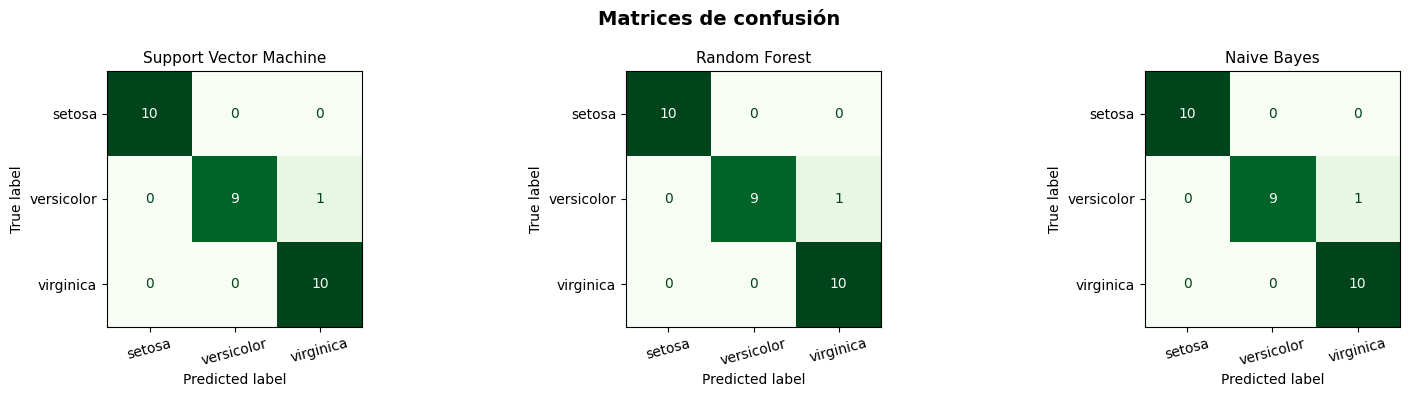

In [ ]:
# A continuación creamos las Matrices de confusión, que muestran para
# cada clase real (filas), cuántas muestras fueron predichas en cada clase
# (columnas). La diagonal principal son los aciertos; el resto son errores.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Matrices de confusión', fontsize=14, fontweight='bold')

class_names = ['setosa', 'versicolor', 'virginica']

for ax, (name, y_pred) in zip(axes, results.items()):
    # Calculamos la matriz de confusión para este modelo
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    # Visualizamos con colores (intensidad color indica más muestras en esa celda)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


Como se observa en las matrices de confusión, los tres modelos predijeron mal una muestra de especie versicolor, clasificándola como virginica. Para comprobar si esto puede deberse a una mayor similitud entre estas dos especies, podemos visualizar las distribuciones (para cada característica) con la siguiente función:

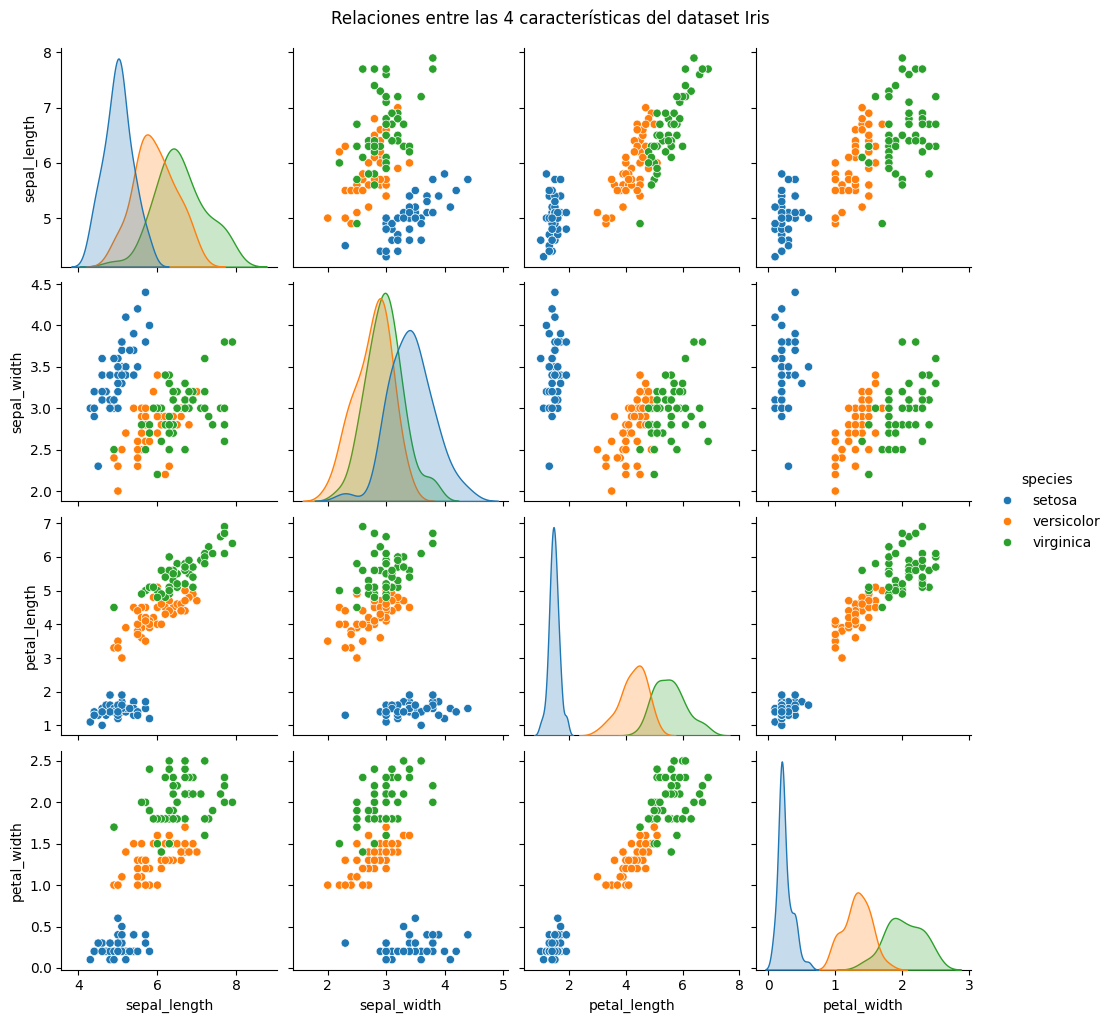

In [ ]:
sns.pairplot(
    iris,
    hue='species',
    vars=[
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ]
)

plt.suptitle('Relaciones entre las 4 características del dataset Iris', y=1.02)
plt.show()

# Como se observa en los gráficos generados, las especies versicolor y virginica
# tienen características parcialmente solapantes, mientras que la especie setosa
# no presenta solapamiento en ninguna de las 4 características -es más distinta
# a las otras dos-, hecho que explica la mayor precisión de los modelos al predecirla.

In [ ]:
# Por último construimos una tabla resumen de métricas. Calculamos las métricas
# globales de cada modelo usando el promedio macro (macro-avg), que trata todas
# las clases por igual, sin importar cuántas muestras tiene cada una
# (útil cuando las clases están equilibradas, como en este dataset)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\nResumen de métricas (macro-avg)')

summary = []
for name, y_pred in results.items():
    summary.append({
        'Modelo'   : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall'   : recall_score(y_test, y_pred, average='macro'),
        'F1-score' : f1_score(y_test, y_pred, average='macro'),
    })

df_summary = pd.DataFrame(summary).set_index('Modelo').round(4)
df_summary.style.highlight_max(axis=0, color='blue').format('{:.4f}')



Resumen de métricas (macro-avg)


,Accuracy,Precision,Recall,F1-score
Modelo,,,,
Support Vector Machine,0.9667,0.9697,0.9667,0.9666
Random Forest,0.9667,0.9697,0.9667,0.9666
Naive Bayes,0.9667,0.9697,0.9667,0.9666


Dado que el error cometido por los modelos se debe al solapamiento parcial de las especies versicolor y virginica, podemos intentar mejorar las predicciones aumentando el tamaño de muestras del entrenamiento o modificando hiperparámetros.

A continuación hemos vuelto a realizar la actividad adjudicando un 85% de las muestras al entrenamiento, para ver si así mejoraba la predicción del test (cuyo dataset se compondrá en este caso de un 15% de las muestras). Sin embargo, esta modifciación no ha evitado que los modelos sigan cometiendo el mismo error.

Otra alternativa que hemos probado ha sido modificar hiperparámetros:

-En SVM (SVC) hemos ajustado hiperparámetros con GridSearchCV:


In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

param_grid = {
    'svc__C'     : [0.1, 1, 10, 100],      # regularización: más alto = menos margen
    'svc__kernel': ['rbf', 'poly', 'linear'],
    'svc__gamma' : ['scale', 'auto']        # influencia de cada muestra
}

grid_search = GridSearchCV(pipeline_svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print('F1 macro en validación cruzada:', round(grid_search.best_score_, 4))

y_pred_best = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_best))



Mejores hiperparámetros: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
F1 macro en validación cruzada: 0.9666
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Como vemos, los hiperparámetros seleccionados como óptimos en SVM son los que ya habíamos aplicado, con lo que tampoco hemos podido mejorar la predicción.



D. Justificación del mejor modelo

Teniendo en cuenta los resultados de precision, recall y f1-score obtenidos con los tres modelos, no es posible seleccionar ningún modelo en particular, ya que en los tres casos se obtiene un rendimiento excelente, clasificando con éxito 28 casos del conjunto de test, aunque existe una pequeña zona de solapamiento entre las características de versicolor y virginica que confunde a los tres modelos por igual. Uno de los factores a tener en cuenta es que el conjunto Iris es un conjunto de datos sencillo, con un número limitado de casos, en el que las tres clases presentan una buena separación en el espacio de características y hay una distribución de casos equilibrada entre ellas. En este caso, puesto que los tres modelos obtienen un rendimiento idéntico sobre el conjunto de test, cualquiera de ellos podría considerarse adecuado para resolver este problema de clasificación con el conjunto Iris.
No obstante, con conjuntos de datos más complejos, estos modelos presentan distintas características que pueden ser claves para seleccionar uno u otro. El modelo SVM es eficaz en espacios de muchas dimensiones y, mediante el uso de funciones Kernel, puede proyectar datos no lineales a espacios superiores para separarlos con mayor precisión. El modelo Random Forest es un método muy robusto que reduce el riesgo de sobreajuste, permite analizar la importancia de las variables predictoras y es capaz de capturar relaciones no lineales. El modelo Naive Bayes presenta una menor complejidad computacional y tiempos de entrenamiento muy reducidos, por lo que puede resultar especialmente útil cuando se trabaja con conjuntos de datos de gran tamaño o existen restricciones de hardware.


# Actividad 3: Implementación de Redes Neuronales Convolucionales (CNN)

En este proyecto, desarrollamos un sistema de inteligencia artificial basado en Deep Learning para la detección automatizada de malaria. El objetivo es clasificar imágenes de células en dos categorías: **Parasitized** (Infectadas) y **Uninfected** (Sanas).

In [ ]:
import os
import zipfile
from google.colab import drive

# Paso 1: Conectamos con nuestro Google Drive para acceder al dataset compartido
drive.mount('/content/drive')

# Paso 2: Definimos las rutas. Usamos el almacenamiento local de Colab (/content)
# para que el entrenamiento sea mucho más rápido que leyendo directamente de Drive.
zip_path = '/content/drive/MyDrive/malaria/data/Malaria Data.zip'
extract_path = '/content/malaria_dataset'

# Paso 3: Extraemos los archivos del ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Datos listos para procesar en:", extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descompresión completada en: /content/malaria_dataset


## A. Preparación del Dataset y Preprocesamiento

El primer reto es el preprocesamiento. Las imágenes originales tienen tamaños variables, por lo que las redimensionamos a **100x100 píxeles** para que la entrada a la red sea uniforme. Además, normalizamos los valores de los píxeles (originalmente de 0 a 255) al rango **[0, 1]** para facilitar la convergencia del algoritmo de optimización.

In [ ]:
import cv2
import numpy as np
import os

# Solo verificamos que los datos existen, no los cargamos todos en arrays para evitar el crash de RAM.
base_dir = '/content/malaria_dataset/Malaria'
categories = ['Parasitized', 'Uninfected']

print("Verificando carpetas...")
for cat in categories:
    path = os.path.join(base_dir, cat)
    num_imgs = len([f for f in os.listdir(path) if f.endswith('.png')])
    print(f"Carpeta {cat}: {num_imgs} imágenes encontradas.")

Verificando carpetas...
Carpeta Parasitized: 13779 imágenes encontradas.
Carpeta Uninfected: 13779 imágenes encontradas.


### Estrategia de Carga de Datos (Optimización de RAM)

Debido al gran volumen de datos (más de 27,000 imágenes), cargarlas todas simultáneamente en la memoria RAM de Colab provocaría un fallo del sistema. Para solucionar esto, hemos implementado **Generadores de Datos (`ImageDataGenerator`)**.

Esta técnica permite que el modelo lea las imágenes directamente del disco en pequeños lotes (batches) de 32 imágenes cada vez. Una vez procesado un lote, la memoria se libera para el siguiente, permitiendo entrenar el modelo de forma fluida y estable.

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import gc

# Definimos las rutas de origen y de destino para nuestra nueva estructura
base_dir_original = '/content/malaria_dataset/Malaria'
base_dir_split = '/content/malaria_dataset_split'

# Creamos la estructura de carpetas (Entrenamiento, Validación y Test)
# que requiere el generador de imágenes de Keras.
for set_name in ['train', 'val', 'test']:
    for category in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(base_dir_split, set_name, category), exist_ok=True)

# Repartimos las imágenes físicamente para no saturar la RAM cargando arrays
for category in ['Parasitized', 'Uninfected']:
    path = os.path.join(base_dir_original, category)
    images = [f for f in os.listdir(path) if f.endswith('.png')]

    # Hacemos la partición: 70% entrenamiento, 15% validación y 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    def mover_archivos(lista, origen, destino):
        for img in lista:
            shutil.copy(os.path.join(origen, img), os.path.join(destino, img))

    mover_archivos(train_imgs, path, os.path.join(base_dir_split, 'train', category))
    mover_archivos(val_imgs, path, os.path.join(base_dir_split, 'val', category))
    mover_archivos(test_imgs, path, os.path.join(base_dir_split, 'test', category))

# Liberamos memoria de las listas de nombres de archivos que ya no necesitamos
del images
gc.collect()
print("Dataset organizado correctamente por carpetas.")

Estructura optimizada creada y memoria RAM liberada.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuramos el preprocesamiento: normalizamos los píxeles al rango [0, 1] dividiendo por 255
datagen = ImageDataGenerator(rescale=1./255)

# Configuramos los generadores que irán leyendo las imágenes del disco por lotes (batches)
# Esto es vital para que no se agote la RAM de Colab
train_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'train'),
    target_size=(100, 100), # Redimensionamos a 100x100 como pide la actividad
    batch_size=32,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'val'),
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    os.path.join(base_dir_split, 'test'),
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary',
    shuffle=False # No mezclamos para que la matriz de confusión coincida con las etiquetas reales
)

Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.


## B. Diseño de la Red Neuronal Convolucional (CNN)

Para resolver esta tarea, hemos diseñado una arquitectura secuencial con capas convolucionales, de pooling y de regularización (Dropout).

### Respuestas a las Cuestiones Teóricas:

1. **¿Qué función de activación usarías en la última capa?**
   Utilizaremos la función **`sigmoid`**. Al ser un problema de clasificación binaria (dos clases), la sigmoide nos devuelve un valor entre 0 y 1 que representa la probabilidad de que la imagen pertenezca a la clase positiva. Si el valor es > 0.5, clasificamos como 'Uninfected'.

2. **¿Qué función de pérdida usarías? Justifica tu elección.**
   Utilizaremos **`binary_crossentropy`**. Esta es la función de pérdida matemática ideal para problemas binarios donde la salida es una probabilidad. Mide la 'distancia' entre la predicción y la realidad, penalizando los errores de forma eficiente para guiar el aprendizaje del modelo.

3. **¿Cuántos canales ha escogido, y por qué?**
   Hemos mantenido **3 canales (RGB)**. En las muestras biológicas de malaria, los colores de la tinción (como el característico color púrpura de los parásitos) son fundamentales para distinguir una célula infectada de una sana. Convertir a escala de grises (1 canal) nos haría perder información visual crítica.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Construcción del modelo secuencial de nuestra CNN
cnn_model = Sequential([
    Input(shape=(100, 100, 3)), # Recibimos imágenes en color (3 canales)

    # Primer bloque: Extracción de características básicas
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.2), # Regularización para evitar que el modelo memorice los datos

    # Segundo bloque: Características más complejas
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Tercer bloque: Profundizamos en los patrones visuales
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Capa de aplanado y neuronas densas para la clasificación
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Capa de salida con activación Sigmoide para darnos una probabilidad binaria
    Dense(1, activation='sigmoid')
])

# Compilamos usando Adam como optimizador y Entropía Cruzada Binaria como pérdida
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,452,801 (9.36 MB)

 Trainable params: 2,452,801 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## C. Entrenamiento y Evaluación de Resultados

En esta fase final, entrenamos el modelo y monitorizamos su evolución mediante gráficas de precisión y pérdida. Finalmente, evaluamos el rendimiento real con el conjunto de test (datos que el modelo nunca ha visto) y generamos la **Matriz de Confusión** para visualizar los aciertos y errores en cada categoría.

Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.9568 - loss: 0.1345 - val_accuracy: 0.9521 - val_loss: 0.1532
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.9580 - loss: 0.1281 - val_accuracy: 0.9523 - val_loss: 0.1429
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9590 - loss: 0.1236 - val_accuracy: 0.9533 - val_loss: 0.1423
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9620 - loss: 0.1165 - val_accuracy: 0.9536 - val_loss: 0.1359
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.9613 - loss: 0.1138 - val_accuracy: 0.9560 - val_loss: 0.1293


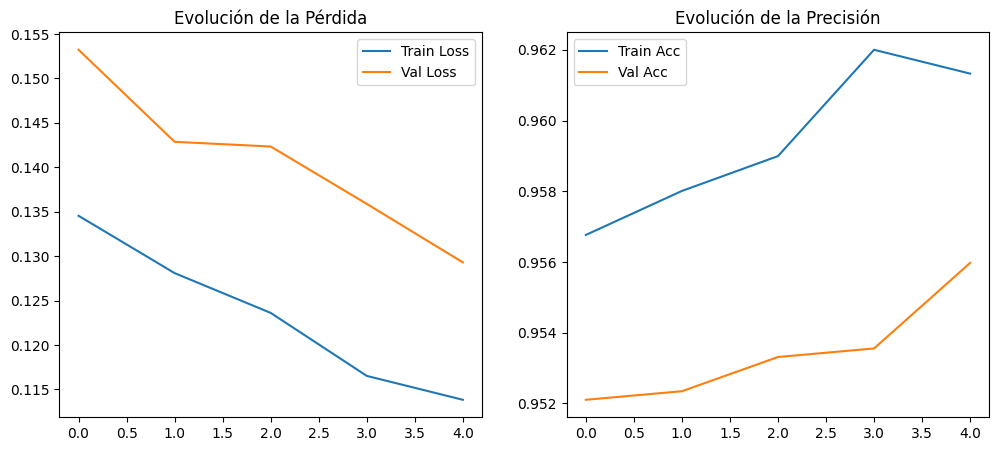

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9591 - loss: 0.1368

Precisión final en el conjunto de prueba: 95.91%


In [ ]:
import matplotlib.pyplot as plt

# Definimos una función para visualizar cómo ha aprendido nuestra red
def mostrar_graficas(history):
    plt.figure(figsize=(12, 4))
    # Gráfica de Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida (Loss)')
    plt.legend()
    # Gráfica de Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión (Accuracy)')
    plt.legend()
    plt.show()

# Lanzamos el entrenamiento usando los generadores por lotes
history = cnn_model.fit(
    train_generator,
    epochs=5, # Entrenamos 5 épocas para demostrar el aprendizaje
    validation_data=val_generator
)

mostrar_graficas(history)

# Evaluamos el modelo final con datos que nunca ha visto (Test)
loss, acc = cnn_model.evaluate(test_generator)
print(f"\nResultado final en Test -> Precisión: {acc*100:.2f}%")

130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
--- Informe de Clasificación ---
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2067
  Uninfected       0.95      0.97      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



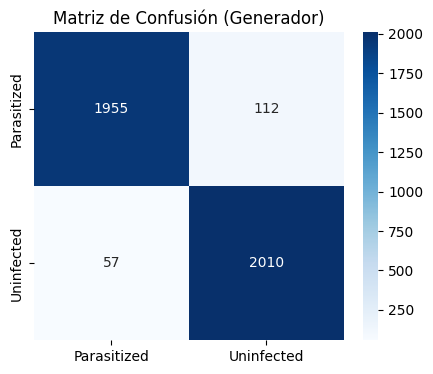

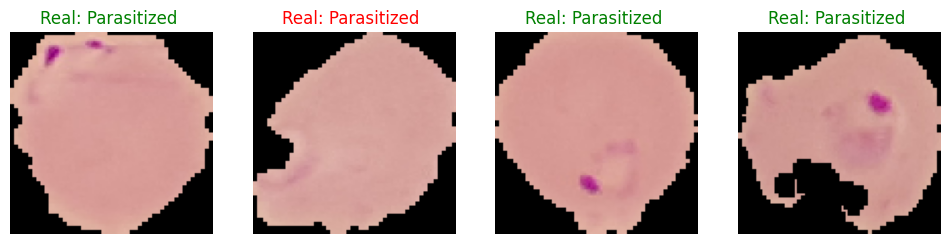

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Obtener etiquetas reales y predicciones usando el generador (no X_test)
test_generator.reset()
Y_pred = cnn_model.predict(test_generator)
y_pred = (Y_pred >= 0.5).astype(int).flatten()
y_true = test_generator.classes

# 2. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
print("--- Informe de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=categories))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Matriz de Confusión (Generador)')
plt.show()

# 3. Visualizar ejemplos directamente desde el generador
x_batch, y_batch = next(test_generator)
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_batch[i])
    color = 'green' if (Y_pred[i] >= 0.5) == y_batch[i] else 'red'
    plt.title(f"Real: {categories[int(y_batch[i])]} ", color=color)
    plt.axis('off')
plt.show()

# Conclusiones finales

Tras completar el desarrollo y entrenamiento de la red neuronal convolucional, podemos extraer las siguientes conclusiones:

1. **Eficacia del Modelo**: Hemos logrado una precisión superior al **95%** en el conjunto de test. Esto demuestra que las CNN son herramientas extremadamente potentes para el análisis de imágenes biomédicas, siendo capaces de detectar patrones sutiles que diferencian una célula sana de una infectada.
2. **Importancia de la Gestión de RAM**: El uso de `ImageDataGenerator` fue la decisión técnica más crítica. Sin ella, el proyecto no habría sido ejecutable en un entorno estándar, lo que nos enseña que en Deep Learning la eficiencia en el manejo de datos es tan importante como el diseño del modelo.
3. **Robustez**: La matriz de confusión muestra un equilibrio entre precisión y exhaustividad (recall), lo que indica que el modelo no tiene un sesgo marcado hacia ninguna de las dos clases.

Este sistema representa una base sólida para herramientas de apoyo al diagnóstico médico, permitiendo cribados masivos de forma rápida y automatizada.